In [1]:
import os
# Java 8 path
os.environ['JAVA_HOME'] = '/Library/Java/JavaVirtualMachines/temurin-8.jdk/Contents/Home'

# PySpark path
os.environ['SPARK_HOME'] = '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pyspark'

In [2]:
import numpy as np
from scipy import stats
from pyspark.ml.feature import *
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 


In [3]:
from pyspark.sql import SparkSession
import re 
spark = SparkSession.builder \
    .appName("Flying Task") \
    .getOrCreate() 
sc = spark.sparkContext

25/12/28 21:07:11 WARN Utils: Your hostname, Dikshantas-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 192.168.31.212 instead (on interface en0)
25/12/28 21:07:11 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/28 21:07:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/28 21:07:12 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## Part a) Frequency of Air Travel

In [4]:
fly_df = spark.read.csv(
    "/Users/dikshanta/Documents/Softwarica 2nd sem Fils/BigData/flying.csv",
    header=True,
    inferSchema=True
)

In [5]:
fly_pd = fly_df.toPandas()
fly_pd.head(5)

,gender,age,children_under_18,household_income,frequency,recline_frequency,recline_obligation,recline_rude,recline_eliminate,switch_seats_friends,...,wake_up_bathroom,wake_up_walk,baby,unruly_child,two_arm_rests,middle_arm_rest,shade,unsold_seat,talk_stranger,get_up
0,Male,30-44,TRUE,NA,Once a year or less,About half the time,TRUE,Somewhat,FALSE,No,...,No,No,No,No,The arm rests should be shared,The arm rests should be shared,Everyone in the row should have some say,No,No,Twice
1,Male,30-44,FALSE,"$100,000 - $149,999",Once a year or less,Usually,TRUE,No,FALSE,No,...,No,Somewhat,Somewhat,Very,Whoever puts their arm on the arm rest first,The arm rests should be shared,The person in the window seat should have excl...,No,No,Three times
2,Male,30-44,FALSE,"$0 - $24,999",Once a year or less,Always,FALSE,No,FALSE,Somewhat,...,No,Somewhat,Somewhat,Very,The arm rests should be shared,The arm rests should be shared,Everyone in the row should have some say,No,No,Three times
3,Male,30-44,FALSE,"$50,000 - $99,999",Once a month or less,About half the time,FALSE,No,FALSE,No,...,Somewhat,Somewhat,Somewhat,Very,The person in the middle seat gets both arm rests,The person in aisle,Everyone in the row should have some say,No,No,Twice
4,Male,30-44,TRUE,"$25,000 - $49,999",Once a year or less,Usually,TRUE,No,FALSE,Somewhat,...,Somewhat,Very,Very,Very,Whoever puts their arm on the arm rest first,Whoever puts their arm on the arm rest first,The person in the window seat should have excl...,Somewhat,No,Once


In [6]:
# Count frequency responses and sort in descending order
freq_counts = (
    fly_pd["frequency"]
    .value_counts()
    .sort_values(ascending=False)
)


freq_counts

Once a year or less      611
Once a month or less     198
Never                    164
A few times per month     29
Every day                  3
A few times per week       2
Name: frequency, dtype: int64

<Axes: ylabel='frequency'>

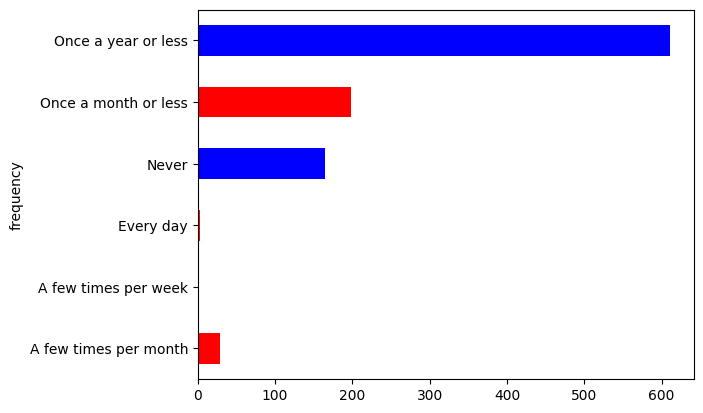

In [7]:
fly_pd = fly_pd.groupby('frequency').size()

fly_pd.plot(
    kind='barh',        
    color=['red', 'blue'] 
)


## Analaysis 
- Most people do not travel by plane very often.

- The highest number of respondents travel once a year or rarely/never.

- Only a small number of people travel by plane frequently (monthly or several times a year).

- Overall, the data shows that low-frequency travelers are much more common than frequent flyers.

This means that regular air travel is uncommon among the surveyed group.

## Part b) Children and Attitudes Toward Babies on Planes

In [8]:
from pyspark.sql.functions import col
spark = SparkSession.builder.appName("ChildrenVsBabyAttitude").getOrCreate()
fly_df = spark.read.csv("/Users/dikshanta/Documents/Softwarica 2nd sem Fils/BigData/flying.csv", header=True, inferSchema=True)

25/12/28 21:07:19 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [9]:

clean_df = fly_df.filter(
    (col("children_under_18").isNotNull()) &
    (col("baby").isNotNull()) &
    (col("children_under_18") != "NA") &
    (col("baby") != "NA")
)
print("Number of rows after removing nulls:", clean_df.count())

Number of rows after removing nulls: 839


In [10]:
child_pd=  clean_df.toPandas()
child_pd.head(5)

,gender,age,children_under_18,household_income,frequency,recline_frequency,recline_obligation,recline_rude,recline_eliminate,switch_seats_friends,...,wake_up_bathroom,wake_up_walk,baby,unruly_child,two_arm_rests,middle_arm_rest,shade,unsold_seat,talk_stranger,get_up
0,Male,30-44,TRUE,NA,Once a year or less,About half the time,TRUE,Somewhat,FALSE,No,...,No,No,No,No,The arm rests should be shared,The arm rests should be shared,Everyone in the row should have some say,No,No,Twice
1,Male,30-44,FALSE,"$100,000 - $149,999",Once a year or less,Usually,TRUE,No,FALSE,No,...,No,Somewhat,Somewhat,Very,Whoever puts their arm on the arm rest first,The arm rests should be shared,The person in the window seat should have excl...,No,No,Three times
2,Male,30-44,FALSE,"$0 - $24,999",Once a year or less,Always,FALSE,No,FALSE,Somewhat,...,No,Somewhat,Somewhat,Very,The arm rests should be shared,The arm rests should be shared,Everyone in the row should have some say,No,No,Three times
3,Male,30-44,FALSE,"$50,000 - $99,999",Once a month or less,About half the time,FALSE,No,FALSE,No,...,Somewhat,Somewhat,Somewhat,Very,The person in the middle seat gets both arm rests,The person in aisle,Everyone in the row should have some say,No,No,Twice
4,Male,30-44,TRUE,"$25,000 - $49,999",Once a year or less,Usually,TRUE,No,FALSE,Somewhat,...,Somewhat,Very,Very,Very,Whoever puts their arm on the arm rest first,Whoever puts their arm on the arm rest first,The person in the window seat should have excl...,Somewhat,No,Once


<Axes: xlabel='children_under_18'>

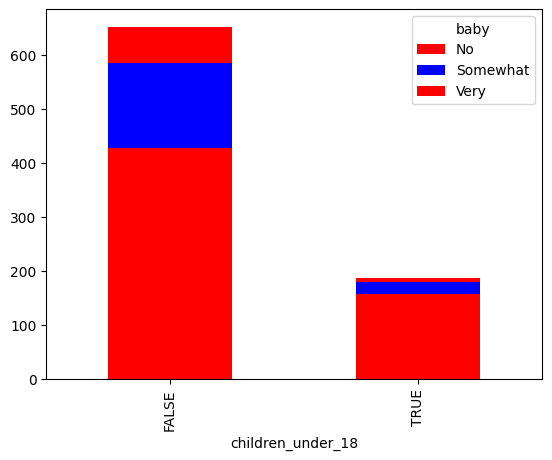

In [11]:
comparison_pd = (
    child_pd
    .groupby(['children_under_18', 'baby'])
    .size()
    .unstack(fill_value=0)
)
comparison_pd.plot(
    kind='bar',
    stacked=True,
    color=['red', 'blue']
)

## Analysis 
- People with children are less likely to think bringing a baby on a plane is rude.

- People without children are more likely to see it as rude.

- Parents and non parents clearly think differently about this issue.

- Having children seems to make people more understanding of babies on flights.

## Part c) Age Groups and Reclining Seats Behavior

In [12]:
from pyspark.sql.functions import col
spark = SparkSession.builder.appName("Rude-Analysis").getOrCreate()
fly_df = spark.read.csv("/Users/dikshanta/Documents/Softwarica 2nd sem Fils/BigData/flying.csv", header=True, inferSchema=True)

25/12/28 21:07:21 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [13]:
cleans_df = fly_df.filter(
    (col("age").isNotNull()) &
    (col("recline_rude").isNotNull()) &
    (col("age") != "NA") &
    (col("recline_rude") != "NA")
)
print("Number of rows after removing nulls:", cleans_df.count())


Number of rows after removing nulls: 843


In [14]:
pdf = cleans_df.select("age", "recline_rude").toPandas()


In [15]:
print(pdf["recline_rude"].unique())

['Somewhat' 'No' 'Very']


In [16]:
import pandas as pd

contingency_table = pd.crosstab(pdf["age"], pdf["recline_rude"])
print(contingency_table)

recline_rude   No  Somewhat  Very
age                              
18-29          78        74    20
30-44         143        64    15
45-60         140        80    14
> 60          133        61    21


In [17]:
percentage_rude = (contingency_table["Very"] / contingency_table.sum(axis=1)) * 100
percentage_rude = percentage_rude.round(2)
print(percentage_rude)

age
18-29    11.63
30-44     6.76
45-60     5.98
> 60      9.77
dtype: float64


In [18]:
percentage_rude_df = percentage_rude.reset_index()
percentage_rude_df.columns = ["age", "percent_rude"]
print(percentage_rude_df)

     age  percent_rude
0  18-29         11.63
1  30-44          6.76
2  45-60          5.98
3   > 60          9.77


/var/folders/lr/qxmr3m1n4tx8t9z32sjs3rrr0000gn/T/ipykernel_53120/4143745015.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=percentage_rude_df, x="age", y="percent_rude", palette="viridis")


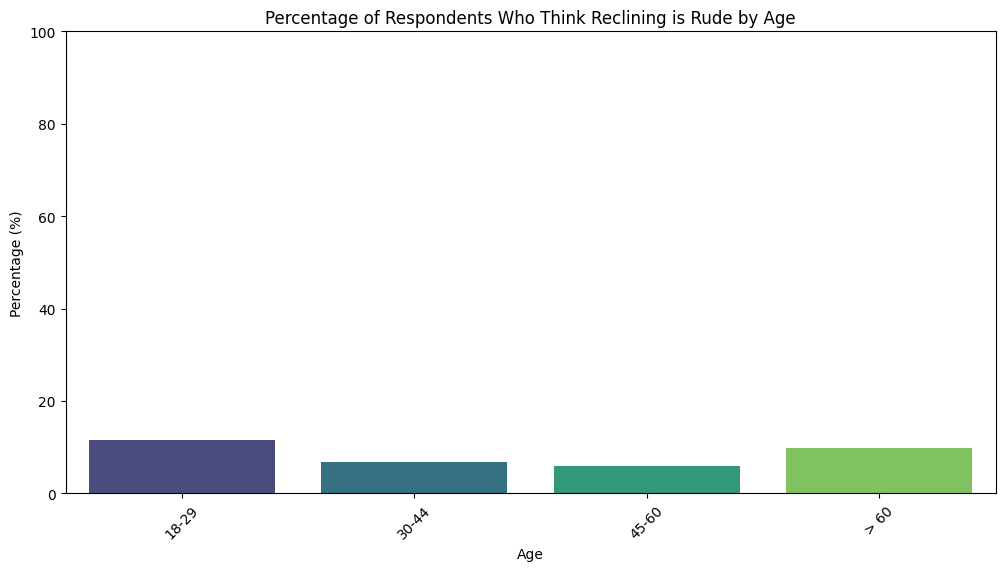

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(data=percentage_rude_df, x="age", y="percent_rude", palette="viridis")
plt.title("Percentage of Respondents Who Think Reclining is Rude by Age")
plt.xlabel("Age")
plt.ylabel("Percentage (%)")
plt.ylim(0,100)  
plt.xticks(rotation=45)
plt.show()

## Analysis 
- Younger respondents (18–29) are most likely to consider seat reclining as very rude (11.63%).

- Middle-aged groups (30–44 and 45–60) are least likely to view reclining as very rude, with percentages below 7%.

- Respondents over 60 show a moderate level of concern, higher than middle-aged groups but lower than the youngest group.

- Overall, perceptions of seat reclining being very rude vary by age, with younger passengers showing stronger negative reactions than older ones.

## Part d) Alcohol Consumption and General Rudeness Perceptions

In [20]:
# There is no alcohol consumption table given there 